# Dystonia Spiking-Network Simulation

**Authors:** Norman Lu and Rodrigo Pena  
**Model:** Leaky integrate-and-fire (LIF) network with two populations  
**Reference:** Table 2 — single-neuron, synaptic, network, and simulation parameters

Populations:
- **FS** (Functional Synergy) — balanced E/I; Pop 1 E cells (gE=2 nS fixed) + I cells (gI=6·s nS)
- **DS** (Dystonic Synergy)  — increased excitation without matching inhibition; Pop 2 E cells (gE=4·s nS)


In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy.ndimage import gaussian_filter

plt.rcParams["font.family"] = "DejaVu Sans"

## Table 2 Parameters

All values match Table 2 of the manuscript exactly.

In [2]:
# ── Table 2: Single-Neuron (LIF) ────────────────────────────────────────────
Cm      = 200.0   # pF   membrane capacitance
gL      = 10.0    # nS   leak conductance
EL      = -65.0   # mV   resting (leak) potential
Vth     = -50.0   # mV   spike threshold
Vreset  = -60.0   # mV   post-spike reset potential
tau_ref = 2.0     # ms   absolute refractory period

# Derived membrane time constant: tau_m = Cm / gL  (pF/nS = ms)
tau_m = Cm / gL   # 20 ms

# ── Table 2: Synaptic ────────────────────────────────────────────────────────
EE      = 0.0     # mV   excitatory reversal potential
EI      = -75.0   # mV   inhibitory reversal potential
tau_syn = 6.0     # ms   synaptic conductance decay time constant
#   gE – Pop.1 E cells  : 2 nS            (fixed)
#   gI – Pop.1 I cells  : 6 × s nS        (scales with input strength s)
#   gE – Pop.2 E cells  : 4 × s nS        (scales with input strength s)

# ── Table 2: Network Structure ────────────────────────────────────────────────
Nex     = 20      # excitatory neurons per population
Ninh    = 5       # inhibitory interneurons (Population 1 only)
Nneuron = Nex + Ninh  # total size of Population 1 = 25
p       = 1.0     # connection probability (all-to-all)

# ── Table 2: External Input / Drive ──────────────────────────────────────────
r_ext   = 8.0     # Hz   baseline external Poisson input rate (both populations)

# ── Table 2: Simulation / Integration ────────────────────────────────────────
dt      = 0.1     # ms   integration time step
tf      = 2000.0  # ms   total simulation time
N       = round(tf / dt)

# ── Axonal conduction delay ───────────────────────────────────────────────────
delay   = 1.5     # ms

## Stimulus Helper

In [3]:
def Ipoisson(rate_hz, dt_ms=dt):
    """
    Return 1 with probability rate_hz * dt_ms * 1e-3 (Poisson spike generator).
    Implements I_ext = A × Poisson(r) from the Methods.
    """
    return int(np.random.rand() < rate_hz * 1e-3 * dt_ms)

## LIF Neuron Class

Biophysical units throughout. Membrane equation (Euler):

$$C_m \\frac{dV}{dt} = -g_L(V - E_L) + I_{syn}$$

Synaptic current:

$$I_{syn} = -g_E\\, s_E\\,(V - E_E) - g_I\\, s_I\\,(V - E_I)$$

In [4]:
class LIFNeuron:
    """
    Leaky integrate-and-fire neuron in biophysical units (Table 2).

    Parameters
    ----------
    nid : int    neuron identifier
    gE  : float  excitatory synaptic weight (nS)  — set per Table 2 rules
    gI  : float  inhibitory synaptic weight (nS)  — set per Table 2 rules
    """

    # Weight for external Poisson drive (fixed at 10 nS; not in Table 2)
    _g_ext = 10.0  # nS

    def __init__(self, nid, gE=2.0, gI=0.0):
        self.nid  = nid
        self.gE   = gE   # nS
        self.gI   = gI   # nS

        # State variables
        self.V    = EL   # mV  membrane potential
        self.sE   = 0.0  # excitatory gating variable
        self.sI   = 0.0  # inhibitory gating variable
        self.sext = 0.0  # external (Poisson) gating variable

        # Spike machinery
        self.ref_count         = 0.0   # ms remaining in refractory period
        self.sendspk           = 0
        self.spktimes          = []

        # Delayed pre-synaptic spike
        self._delay_remaining  = 0.0
        self._pending_type     = None  # 'E' or 'I'

    # ── Synaptic current ──────────────────────────────────────────────────
    def _I_syn(self):
        I_exc = self.gE       * self.sE   * (self.V - EE)
        I_inh = self.gI       * self.sI   * (self.V - EI)
        I_ext = self._g_ext   * self.sext * (self.V - EE)
        return -(I_exc + I_inh + I_ext)   # positive = depolarising

    # ── Euler step ────────────────────────────────────────────────────────
    def step(self, t):
        """Advance one Euler step of size dt (ms)."""
        self.sendspk = 0

        # Deliver delayed pre-synaptic spike
        if self._delay_remaining > 0:
            self._delay_remaining -= dt
            if self._delay_remaining <= 0:
                self._delay_remaining = 0.0
                if self._pending_type == 'E':
                    self.sE += 1.0
                elif self._pending_type == 'I':
                    self.sI += 1.0
                self._pending_type = None

        # Decay synaptic gating variables (exponential decay, tau_syn)
        self.sE   += dt * (-self.sE   / tau_syn)
        self.sI   += dt * (-self.sI   / tau_syn)
        self.sext += dt * (-self.sext / tau_syn)

        # Hold at Vreset during refractory period
        if self.ref_count > 0:
            self.ref_count -= dt
            self.V = Vreset
            return

        # Membrane potential update (Euler)
        dV = (-(self.V - EL) + self._I_syn() / gL) / tau_m
        self.V += dt * dV

        # Spike detection and reset
        if self.V >= Vth:
            self.V = Vreset
            self.ref_count = tau_ref
            self.spktimes.append(t)
            self.sendspk = 1

    # ── Pre-synaptic spike arrival ────────────────────────────────────────
    def add_pre_spike(self, syn_type='E', axon_delay=delay):
        """Queue a pre-synaptic spike with axonal conduction delay."""
        self._delay_remaining = axon_delay
        self._pending_type    = syn_type

    def add_external(self):
        """Increment external Poisson gating variable (Iext = A × Poisson(r))."""
        self.sext += 1.0

## Network Builders

**Population 1 — FS (Functional Synergy):** balanced E/I.  
- E cells: gE = 2 nS (fixed)  
- I cells: gI = 6·s nS (scales with input strength *s*)  

**Population 2 — DS (Dystonic Synergy):** E/I imbalance imposed.  
- E cells: gE = 4·s nS (scales with *s*; no matching inhibition)

In [5]:
def build_population_FS(s):
    """
    Population 1: Functional Synergy — balanced E/I network.

    Table 2:
      gE (E cells) = 2 nS         (fixed)
      gI (I cells) = 6 × s nS     (scales with input strength s)
    """
    neurons  = []
    synapses = []   # list of [(target_idx, syn_type), …]

    # Excitatory cells (indices 0 … Nex-1): receive inhibitory input from I cells
    for i in range(Nex):
        neurons.append(LIFNeuron(nid=i, gE=2.0))
        synapses.append([(j, 'I') for j in range(Nex, Nneuron)])

    # Inhibitory cells (indices Nex … Nneuron-1): receive excitatory input from E cells
    gI_val = 6.0 * s
    for i in range(Nex, Nneuron):
        neurons.append(LIFNeuron(nid=i, gI=gI_val))
        synapses.append([(j, 'E') for j in range(Nex)])

    return neurons, synapses


def build_population_DS(s):
    """
    Population 2: Dystonic Synergy — E/I imbalance (increased excitation, no matching inhibition).

    Table 2:
      gE (E cells) = 4 × s nS     (scales with input strength s)
    """
    neurons  = []
    synapses = []

    for i in range(Nex):
        neurons.append(LIFNeuron(nid=i, gE=4.0 * s))
        synapses.append([])   # no recurrent inhibition

    return neurons, synapses

## Single Simulation Run

In [6]:
def run_simulation(s, seed=42):
    """
    Simulate FS and DS populations for input strength s.

    Euler integration with dt = 0.1 ms, T = 2000 ms (Table 2).
    External drive: Poisson at r_ext = 8 Hz (Table 2).

    Parameters
    ----------
    s    : float  input strength (dimensionless; scales synaptic weights)
    seed : int    random seed for reproducibility

    Returns
    -------
    rate_fs, rate_ds : float  population-averaged firing rates (Hz)
    df_fs, df_ds     : DataFrame  spike times per population
    """
    np.random.seed(seed)

    fs_neurons, fs_syn = build_population_FS(s)
    ds_neurons, ds_syn = build_population_DS(s)

    for step_idx in range(N - 1):
        t = step_idx * dt

        # ── FS population ─────────────────────────────────────────────────
        for n_idx, neuron in enumerate(fs_neurons):
            if n_idx < Nex and Ipoisson(r_ext):
                neuron.add_external()
            neuron.step(t)
            if neuron.sendspk and fs_syn[n_idx]:
                for (tgt, stype) in fs_syn[n_idx]:
                    fs_neurons[tgt].add_pre_spike(syn_type=stype)

        # ── DS population ─────────────────────────────────────────────────
        for n_idx, neuron in enumerate(ds_neurons):
            if Ipoisson(r_ext):
                neuron.add_external()
            neuron.step(t)
            if neuron.sendspk and ds_syn[n_idx]:
                for (tgt, stype) in ds_syn[n_idx]:
                    ds_neurons[tgt].add_pre_spike(syn_type=stype)

    # Collect spikes into DataFrames
    def collect_spikes(neurons, pop_label):
        rows = [{'nid': n.nid, 'spktime': t, 'pop': pop_label}
                for n in neurons for t in n.spktimes]
        return pd.DataFrame(rows, columns=['nid', 'spktime', 'pop'])

    df_fs = collect_spikes(fs_neurons, 'FS')
    df_ds = collect_spikes(ds_neurons, 'DS')

    T_s = tf * 1e-3   # ms → s
    rate_fs = len(df_fs) / (Nex * T_s)
    rate_ds = len(df_ds) / (Nex * T_s)

    return rate_fs, rate_ds, df_fs, df_ds

## Raster Plot — Single Run (s = 1.0)

Running single simulation (s = 1.0) …
  Done in 3.9 s
  FS firing rate: 1.43 Hz
  DS firing rate: 0.85 Hz


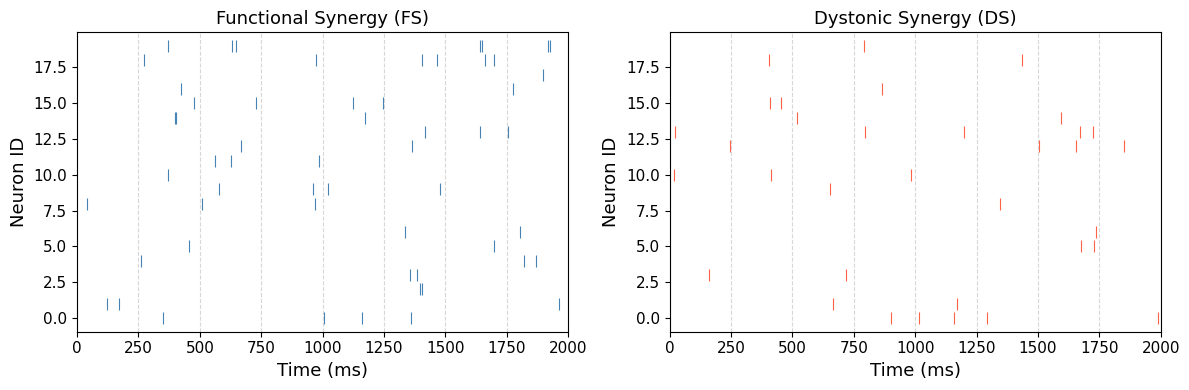

In [7]:
print("Running single simulation (s = 1.0) …")
t0 = time.time()
rate_fs_s1, rate_ds_s1, df_fs_s1, df_ds_s1 = run_simulation(s=1.0, seed=0)
print(f"  Done in {time.time()-t0:.1f} s")
print(f"  FS firing rate: {rate_fs_s1:.2f} Hz")
print(f"  DS firing rate: {rate_ds_s1:.2f} Hz")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, df, label, color in zip(
        axes,
        [df_fs_s1, df_ds_s1],
        ['Functional Synergy (FS)', 'Dystonic Synergy (DS)'],
        ['steelblue', 'tomato']):
    if df.empty:
        ax.text(0.5, 0.5, 'no spikes', ha='center', va='center',
                transform=ax.transAxes, fontsize=13)
    else:
        ax.scatter(df['spktime'], df['nid'],
                   marker='|', color=color, s=80, linewidths=0.8)
    ax.set_xlabel('Time (ms)', fontsize=13)
    ax.set_ylabel('Neuron ID', fontsize=13)
    ax.set_title(label, fontsize=13)
    ax.set_xlim([0, tf])
    ax.grid(True, axis='x', linestyle='--', alpha=0.5)
    ax.tick_params(labelsize=11)

plt.tight_layout()
plt.savefig('raster_s1.pdf')
plt.savefig('raster_s1.png', dpi=150)
plt.show()